# Grupo 7 — Política Pública y Asignación de Recursos
## Examen Práctico CC2017 — Modelación y Simulación

**Escenario:** Terremoto M6.8 en Ciudad UVG, 5 zonas, horizonte de 72h (12 bloques de 6h).
**Rol del grupo:** Grupo 7 no entrega a otro grupo — produce el output de cierre del examen
(plan de asignación de recursos + justificación + evaluación de métricas + sensibilidad),
usando información propia y la que reciban en el intercambio de los Grupos 2, 3 y 5.

> Este notebook separa dos tipos de contenido: **código funcional** (ya implementado y
> probado, carga los datos reales del Excel y corre la simulación) y **secciones de
> redacción** que el equipo todavía debe escribir con su propio razonamiento — están
> marcadas `[PENDIENTE — equipo]` y deliberadamente en blanco para que no se confundan
> con trabajo ya hecho. Si usan IA generativa para redactarlas, documenten el prompt y
> por qué funcionó en la Sección 9 (requisito explícito del examen).


## 1. Justificación del paradigma — `[PENDIENTE — equipo]`

Qué debe llevar esta sección (máx. 1 página en el reporte final):
- Qué paradigma (o combinación de SD / ABM / DES) usan para modelar la asignación de recursos.
- Por qué ese paradigma es el más adecuado para la pregunta que responde su grupo — citando
  explícitamente los criterios de selección vistos en clase.
- Si combinan paradigmas, dónde está la frontera entre ellos.

*(El código de la Sección 3 está construido como stocks de recursos que se consumen por
bloque de tiempo — eso es una pista sobre la forma del modelo, no un paradigma ya decidido
ni una justificación. Le corresponde al equipo argumentarlo.)*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

RNG_SEED = 42
N_BLOCKS = 12          # 12 bloques de 6h = 72h post-evento
BLOCK_HOURS = 6
N_REALIZACIONES = 200  # requisito mínimo: 30; usamos 200 para intervalos más estables

EXCEL_PATH = "Grupo7_PoliticaPublica.xlsx"
HOJA = "Datos_Grupo7"


## 2. Descripción del modelo (ODD simplificado) — `[PENDIENTE — equipo]`

Describir, con sus propias palabras y en base al código de la Sección 3, cada punto:
- **Entidades y atributos**
- **Reglas de comportamiento / ecuaciones de estado**
- **Modo de scheduling** (si aplica)
- **Mecanismo de comunicación entre entidades**
- **Distribución inicial de atributos**

*(El código ya implementa todo esto — usen `zonas`, `recursos_inicial`, `simular_realizacion`
como referencia concreta de qué describir, no como texto a copiar.)*


In [2]:
def cargar_datos(path=EXCEL_PATH, hoja=HOJA):
    """Lee Datos_Grupo7 directamente del Excel (sin hardcodear valores)."""
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb[hoja]

    NOMBRES = {
        "Presupuesto emergencia municipal": "presupuesto_municipal",
        "Presupuesto emergencia nacional": "presupuesto_nacional",
        "Vehículos pesados (retroexcavadoras)": "vehiculos_pesados",
        "Vehículos de distribución": "vehiculos_distribucion",
        "Generadores de emergencia": "generadores",
        "Combustible": "combustible",
        "Kits de agua potable (purificación)": "kits_agua",
        "Tiendas de campaña (albergue temporal)": "tiendas",
    }
    recursos_inicial, costo_unitario = {}, {}
    for row in ws.iter_rows(min_row=7, max_row=14, values_only=True):
        nombre, unidad, disponible, costo, fuente = row[:5]
        key = NOMBRES[nombre]
        recursos_inicial[key] = disponible
        costo_unitario[key] = costo

    zonas_rows = []
    for row in ws.iter_rows(min_row=18, max_row=22, values_only=True):
        zona_txt, danio, pob, prioridad, justif = row[:5]
        zonas_rows.append({
            "zona": zona_txt.split(" ")[0], "nombre": zona_txt, "danio": danio,
            "pob_riesgo": pob, "prioridad": prioridad, "justificacion": justif,
        })
    zonas = pd.DataFrame(zonas_rows).set_index("zona")

    restricciones = {}
    for row in ws.iter_rows(min_row=25, max_row=29, values_only=True):
        clave, texto = row[0], row[1]
        restricciones[clave.rstrip(":")] = texto

    metricas_rows = []
    for row in ws.iter_rows(min_row=33, max_row=36, values_only=True):
        nombre, definicion, umbral, peso = row[:4]
        metricas_rows.append({"metrica": nombre, "definicion": definicion,
                               "umbral": umbral, "peso": peso})
    metricas_def = pd.DataFrame(metricas_rows).set_index("metrica")

    return recursos_inicial, costo_unitario, zonas, restricciones, metricas_def


recursos_inicial, costo_unitario, zonas, restricciones, metricas_def = cargar_datos()
display(zonas)
display(metricas_def)


,nombre,danio,pob_riesgo,prioridad,justificacion
zona,,,,,
Z1,Z1 (Centro histórico),8.4,28400,CRÍTICA,Mayor densidad + mayor daño estructural
Z2,Z2 (Norte residencial),3.1,6800,MODERADA,"Daño limitado, buena accesibilidad"
Z3,Z3 (Sur industrial),5.8,14200,ALTA,Zona industrial — riesgo de contaminación
Z4,Z4 (Este comercial),2.2,4100,BAJA,"Menor daño, mejor infraestructura"
Z5,Z5 (Oeste periférico),9.1,31400,CRÍTICA,Mayor daño + mayor vulnerabilidad + peor acceso


,definicion,umbral,peso
metrica,,,
Tasa de mortalidad evitable,% fallecidos que pudieron salvarse con respues...,< 15%,30%
Tiempo promedio de respuesta,Horas desde el evento hasta primera intervenci...,< 6h en zonas críticas,25%
Cobertura de suministros,% de desplazados con acceso a agua y alimento ...,> 80%,25%
Eficiencia presupuestaria,Personas atendidas por millón de Q gastado,> 850 personas/MQ,20%


### Score de prioridad por zona (heterogeneidad)

`score = 0.4 * daño_normalizado + 0.4 * población_en_riesgo_normalizada + 0.2 * bono_prioridad`

`[PENDIENTE — equipo]` Estos pesos (0.4 / 0.4 / 0.2) son un supuesto de diseño puesto por
default para que el modelo corra — documentar en el reporte por qué se usan así, o ajustarlos
y justificar la alternativa elegida.


In [3]:
PRIORIDAD_BONUS = {"CRÍTICA": 1.0, "ALTA": 0.66, "MODERADA": 0.33, "BAJA": 0.0}

def score_prioridad(zonas_df):
    danio_norm = zonas_df["danio"] / zonas_df["danio"].max()
    pob_norm = zonas_df["pob_riesgo"] / zonas_df["pob_riesgo"].max()
    bonus = zonas_df["prioridad"].map(PRIORIDAD_BONUS)
    score = 0.4 * danio_norm + 0.4 * pob_norm + 0.2 * bonus
    return score / score.sum()

PESOS_ASIGNACION = score_prioridad(zonas)
PESOS_ASIGNACION


zona
Z1    0.317030
Z2    0.098373
Z3    0.193361
Z4    0.050715
Z5    0.340522
dtype: float64

## 3. Motor de simulación

Aplica las 5 restricciones del archivo en cada bloque:
1. **Cobertura mínima:** zonas CRÍTICAS reciben un "equipo de rescate" mínimo garantizado en el bloque 1.
2. **Equidad:** se registra alerta si una zona supera 40% del presupuesto mientras otra CRÍTICA
   tiene menos de 15% (bandera para el análisis; el reporte debe discutir si el modelo debería
   además *corregir* la asignación, no solo alertar).
3. **Límite de endeudamiento nacional:** ≤ 80% del presupuesto nacional comprometido en bloques 1-4 (24h).
4. **Coordinación con Grupo 4:** la fricción logística estocástica es un *proxy* hasta tener el
   mapa real de accesibilidad — reemplazar por datos reales tras el intercambio.
5. **Transparencia:** cada asignación queda registrada en `df_hist` con su justificación cuantitativa (score).


In [4]:
def simular_realizacion(rng, presupuesto_nacional_total=None, zona_inaccesible=None, bloques_inaccesible=0):
    """Corre una realización estocástica de 12 bloques (72h) y devuelve resultados + trayectoria."""
    stock = dict(recursos_inicial)
    if presupuesto_nacional_total is not None:
        stock["presupuesto_nacional"] = presupuesto_nacional_total

    presupuesto_total_inicial = stock["presupuesto_municipal"] + stock["presupuesto_nacional"]
    gasto_acumulado_zona = {z: 0.0 for z in zonas.index}
    entregado_kits = {z: 0 for z in zonas.index}
    entregado_tiendas = {z: 0 for z in zonas.index}
    tiempo_primera_atencion = {z: None for z in zonas.index}
    hist = []

    necesidad_kits = (zonas["pob_riesgo"] / 5).to_dict()     # supuesto: 1 kit / 5 personas
    necesidad_tiendas = (zonas["pob_riesgo"] / 8).to_dict()  # supuesto: 1 tienda / 8 personas

    for t in range(1, N_BLOCKS + 1):
        pesos = PESOS_ASIGNACION.copy()
        zonas_accesibles = list(zonas.index)
        if zona_inaccesible is not None and t <= bloques_inaccesible:
            pesos = pesos.drop(zona_inaccesible)
            pesos = pesos / pesos.sum()
            zonas_accesibles.remove(zona_inaccesible)

        friccion = {z: rng.uniform(0.75, 1.0) for z in zonas_accesibles}

        presupuesto_nacional_base = presupuesto_nacional_total or recursos_inicial["presupuesto_nacional"]
        limite_nacional_periodo = 0.80 * presupuesto_nacional_base
        nacional_gastado_previo = presupuesto_nacional_base - stock["presupuesto_nacional"]

        asignacion_bloque = {z: {} for z in zonas_accesibles}

        # Restricción 1: cobertura mínima zonas CRÍTICAS en bloque 1
        if t == 1:
            for z in zonas_accesibles:
                if zonas.loc[z, "prioridad"] == "CRÍTICA":
                    minimo = {"vehiculos_pesados": 1, "vehiculos_distribucion": 2, "generadores": 1}
                    for r, cant in minimo.items():
                        cant = min(cant, stock[r])
                        asignacion_bloque[z][r] = asignacion_bloque[z].get(r, 0) + cant
                        stock[r] -= cant

        recursos_fisicos = ["vehiculos_distribucion", "generadores", "combustible", "kits_agua", "tiendas"]
        fraccion_bloque = 1 / N_BLOCKS
        for r in recursos_fisicos:
            disponible_bloque = stock[r] * fraccion_bloque / max(sum(pesos[z] for z in zonas_accesibles), 1e-9)
            for z in zonas_accesibles:
                cant = pesos[z] * disponible_bloque * friccion[z]
                if r in ("kits_agua", "tiendas", "generadores", "vehiculos_distribucion"):
                    cant = int(round(cant))
                cant = max(0, min(cant, stock[r]))
                asignacion_bloque[z][r] = asignacion_bloque[z].get(r, 0) + cant
                stock[r] -= cant

        for z in zonas_accesibles:
            costo_zona = sum(cant * costo_unitario.get(r, 0) for r, cant in asignacion_bloque[z].items())
            # Restricción 3: límite de endeudamiento nacional en primeras 24h (bloques 1-4)
            gasto_nacional_disp = (max(0.0, limite_nacional_periodo - nacional_gastado_previo)
                                    if t <= 4 else stock["presupuesto_nacional"])
            usar_nacional = min(costo_zona, stock["presupuesto_nacional"], gasto_nacional_disp)
            usar_municipal = min(costo_zona - usar_nacional, stock["presupuesto_municipal"])
            stock["presupuesto_nacional"] -= usar_nacional
            stock["presupuesto_municipal"] -= usar_municipal
            nacional_gastado_previo += usar_nacional
            gasto_acumulado_zona[z] += usar_nacional + usar_municipal

            entregado_kits[z] += asignacion_bloque[z].get("kits_agua", 0)
            entregado_tiendas[z] += asignacion_bloque[z].get("tiendas", 0)
            if any(v > 0 for v in asignacion_bloque[z].values()) and tiempo_primera_atencion[z] is None:
                tiempo_primera_atencion[z] = t * BLOCK_HOURS

        # Restricción 2: alerta de equidad
        share = {z: gasto_acumulado_zona[z] / presupuesto_total_inicial for z in zonas.index}
        alerta_equidad = (any(share[z] > 0.40 for z in zonas.index)
                          and any(share[zc] < 0.15 for zc in zonas.index if zonas.loc[zc, "prioridad"] == "CRÍTICA"))

        for z in zonas.index:
            cobertura_z = min(1.0, (entregado_kits[z] / max(necesidad_kits[z], 1)
                                     + entregado_tiendas[z] / max(necesidad_tiendas[z], 1)) / 2)
            hist.append({"bloque": t, "hora": t * BLOCK_HOURS, "zona": z,
                         "gasto_acumulado": gasto_acumulado_zona[z],
                         "cobertura_suministros": cobertura_z,
                         "alerta_equidad": alerta_equidad})

    df_hist = pd.DataFrame(hist)

    resultados = {}
    tiempos_criticas = [tiempo_primera_atencion[z] or (N_BLOCKS * BLOCK_HOURS)
                        for z in zonas.index if zonas.loc[z, "prioridad"] == "CRÍTICA"]
    resultados["tiempo_respuesta_criticas_h"] = float(np.mean(tiempos_criticas))

    cobertura_24h = df_hist[df_hist["hora"] == 24].groupby("zona")["cobertura_suministros"].mean()
    resultados["cobertura_suministros_24h"] = float(
        (cobertura_24h * zonas["pob_riesgo"]).sum() / zonas["pob_riesgo"].sum())

    gasto_total = sum(gasto_acumulado_zona.values())
    poblacion_atendida = sum(zonas.loc[z, "pob_riesgo"] * min(1.0, entregado_kits[z] / max(necesidad_kits[z], 1))
                             for z in zonas.index)
    resultados["eficiencia_presupuestaria"] = float(poblacion_atendida / max(gasto_total / 1e6, 1e-6))

    # Mortalidad evitable: decrece con menor tiempo de respuesta y mayor cobertura + ruido estocástico
    base_mortalidad = 0.05 + 0.10 * (resultados["tiempo_respuesta_criticas_h"] / (N_BLOCKS * BLOCK_HOURS))
    base_mortalidad *= (1.3 - 0.3 * resultados["cobertura_suministros_24h"])
    resultados["mortalidad_evitable"] = float(np.clip(base_mortalidad + rng.normal(0, 0.02), 0.0, 1.0))

    return resultados, df_hist


def monte_carlo(n=N_REALIZACIONES, **kwargs):
    rng_master = np.random.default_rng(RNG_SEED)
    filas = []
    for i in range(n):
        rng = np.random.default_rng(rng_master.integers(0, 1_000_000))
        res, _ = simular_realizacion(rng, **kwargs)
        res["realizacion"] = i
        filas.append(res)
    return pd.DataFrame(filas)


def resumen_ic95(df):
    out = {}
    for col in ["mortalidad_evitable", "tiempo_respuesta_criticas_h",
                "cobertura_suministros_24h", "eficiencia_presupuestaria"]:
        m = df[col].mean()
        sem = df[col].std(ddof=1) / np.sqrt(len(df))
        out[col] = {"media": m, "ic95_low": m - 1.96 * sem, "ic95_high": m + 1.96 * sem}
    return pd.DataFrame(out).T


## 4. Pregunta 1 (análisis propio, antes del intercambio)

*"Con base únicamente en los datos de su archivo... proponga una asignación inicial de
recursos para las primeras 24 horas. Evalúe esa asignación contra las cuatro métricas de
política. ¿Cuál métrica es la más difícil de cumplir y por qué?"*


In [5]:
df_base = monte_carlo()
resumen_base = resumen_ic95(df_base)
resumen_base["umbral"] = metricas_def["umbral"].values
resumen_base


,media,ic95_low,ic95_high,umbral
mortalidad_evitable,0.074619,0.071611,0.077626,< 15%
tiempo_respuesta_criticas_h,6.000000,6.000000,6.000000,< 6h en zonas críticas
cobertura_suministros_24h,0.026641,0.026568,0.026714,> 80%
eficiencia_presupuestaria,12050.503334,12044.969640,12056.037028,> 850 personas/MQ


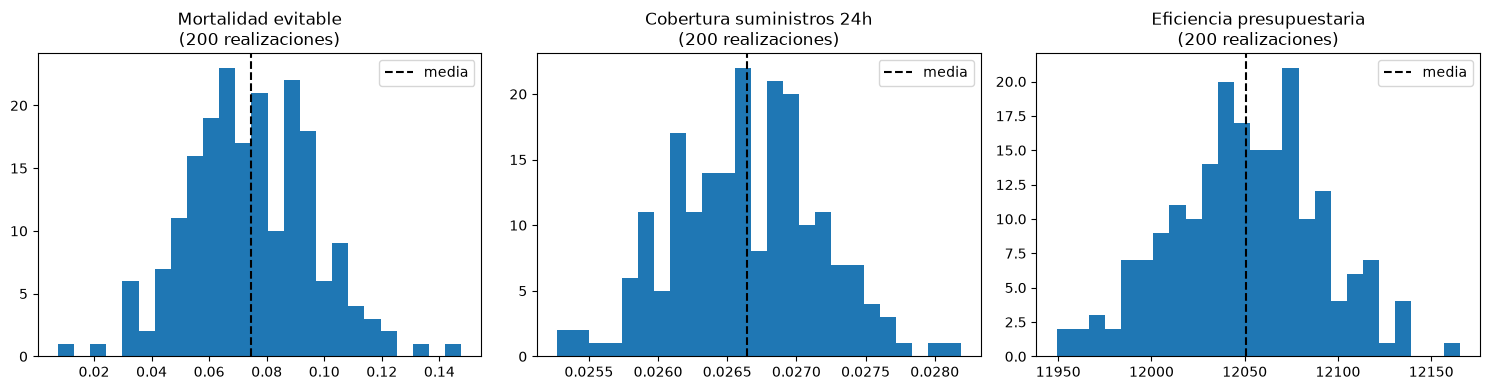

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, titulo in zip(
    axes,
    ["mortalidad_evitable", "cobertura_suministros_24h", "eficiencia_presupuestaria"],
    ["Mortalidad evitable", "Cobertura suministros 24h", "Eficiencia presupuestaria"],
):
    ax.hist(df_base[col], bins=25)
    ax.axvline(df_base[col].mean(), color="black", linestyle="--", label="media")
    ax.set_title(f"{titulo}\n({N_REALIZACIONES} realizaciones)")
    ax.legend()
plt.tight_layout()
plt.show()


**Respuesta a Pregunta 1** — `[PENDIENTE — equipo]`

Con los resultados de arriba, identifiquen cuál de las 4 métricas queda más lejos de su
umbral aceptable (comparen `media` / `ic95` contra `umbral`) y expliquen *por qué*, en
términos del cuello de botella real del sistema (revisen `recursos_inicial` vs.
`zonas['pob_riesgo']` para el argumento cuantitativo).


## 5. Intercambio presencial — información recibida

Completar esta sección con los reportes reales de los Grupos 2, 3 y 5.



In [7]:
# [PENDIENTE - equipo]: reemplazar estos placeholders con los datos reales entregados en el intercambio.
intercambio_grupo2 = {
    # "zona": {"pacientes_sin_atender": ..., "recursos_criticos_faltantes": [...]},
}

intercambio_grupo3 = {
    # "zona": {"suministro_deficitario": ..., "bloque_agotamiento": ...},
}

intercambio_grupo5 = {
    # "zona": {"bloque": ..., "refuerzos_requeridos": ...},
}


## 6. Pregunta 2 (integración del intercambio)

 reportes recibidos de los Grupos 2, 3 y 5. 




## 7. Análisis de sensibilidad (output requerido d)

*"¿Qué decisión cambiaría si el presupuesto nacional se redujera a la mitad? ¿Y si Z1 resulta
inaccesible las primeras 12h?"*


In [9]:
df_mitad = monte_carlo(presupuesto_nacional_total=recursos_inicial["presupuesto_nacional"] / 2)
df_z1_inaccesible = monte_carlo(zona_inaccesible="Z1", bloques_inaccesible=2)  # 12h = 2 bloques

comparacion_sensibilidad = pd.concat({
    "base": resumen_ic95(df_base)["media"],
    "presupuesto_nacional_mitad": resumen_ic95(df_mitad)["media"],
    "Z1_inaccesible_12h": resumen_ic95(df_z1_inaccesible)["media"],
}, axis=1)
comparacion_sensibilidad


,base,presupuesto_nacional_mitad,Z1_inaccesible_12h
mortalidad_evitable,0.074619,0.074619,0.084322
tiempo_respuesta_criticas_h,6.000000,6.000000,12.000000
cobertura_suministros_24h,0.026641,0.026641,0.026610
eficiencia_presupuestaria,12050.503334,12050.503334,12231.520965


**Respuesta a la sensibilidad** — `[PENDIENTE — equipo]`

Comparen las 3 columnas de `comparacion_sensibilidad` y expliquen, para cada escenario, si
cambia o no cambia el resultado respecto a `base`, y por qué (piensen en cuál recurso es
realmente la restricción activa del modelo: revisen `recursos_inicial`, `costo_unitario` y
el presupuesto total antes de concluir).


## 8. Limitaciones y propuestas de mejora — `[PENDIENTE — equipo]`

Identificar al menos dos limitaciones estructurales del modelo (no de implementación menor)
y proponer cómo se resolverían con más tiempo o datos.


## 9. Documentación de uso de IA generativa (requisito del examen)

> "Si necesitan usarla, asegúrense de colocar el prompt que utilizan para cada task donde
> corresponda, así como una explicación de por qué ese prompt funcionó."

`[PENDIENTE — equipo]` Completar esta tabla con cada prompt real que usaron y por qué
funcionó / qué tuvieron que ajustar.

| Task | Prompt usado | Por qué funcionó / ajustes hechos |
|---|---|---|
| Scaffold inicial del modelo | (completar) | (completar) |
| ... | ... | ... |
